# 1. Khai báo thư viện

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42

# 2. Cài đặt đường dẫn & Mở Dữ liệu

In [2]:
dataset_path = 'dynamic_gesture.csv'
model_save_path = 'dynamic_gesture_model.hdf5'
tflite_save_path = 'dynamic_gesture.tflite'
label_path = 'dynamic_gesture_label.csv'
NUM_CLASSES = 10

In [3]:
# Đọc nhãn
with open(label_path, 'r', encoding='utf-8') as f:
    labels = [line.strip() for line in f.readlines()]
print("Các nhãn quỹ đạo:", labels)

# Load dữ liệu nếu có
if os.path.exists(dataset_path) and os.path.getsize(dataset_path) > 0:
    dataset = pd.read_csv(dataset_path, header=None)
    X = dataset.iloc[:, 1:].values
    y = dataset.iloc[:, 0].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=RANDOM_SEED, stratify=y)
    print("Mẫu Train:", X_train.shape[0])
    print("Mẫu Test:", X_test.shape[0])
else:
    print("Chưa có tệp data, bạn hãy chạy test.py để thu thập dữ liệu (Bấm phím 'h')")


Các nhãn quỹ đạo: ['Swipe Left', 'Swipe Right', 'Clockwise Circle', 'Counter Clockwise Circle', 'Swipe Down', 'Swipe Up', 'Triangle', 'Infinity', 'Z-Shape', 'S-Shape']
Mẫu Train: 23538
Mẫu Test: 7847


# 3. Model Động (Mạng nhỏ xử lý 64 tham số tọa độ - Do tăng history_length lên 32)

In [4]:
# Dữ liệu vào là mảng 2D (32 điểm * 2 x,y = 64)
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(64, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 128)               8320      
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 17226 (67.29 KB)
Trainable params: 17226 (67.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# 4. Huấn luyện Model

In [5]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(model_save_path, verbose=1, save_weights_only=False)
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

if 'X_train' in locals():
    history = model.fit(
        X_train,
        y_train,
        epochs=1000,
        batch_size=128,
        validation_data=(X_test, y_test),
        callbacks=[cp_callback, es_callback]
    )



Epoch 1/1000


169/184 [==========================>...] - ETA: 0s - loss: 2.2258 - accuracy: 0.1650
Epoch 1: saving model to dynamic_gesture_model.hdf5
184/184 [==============================] - 2s 4ms/step - loss: 2.2159 - accuracy: 0.1719 - val_loss: 2.0087 - val_accuracy: 0.3199
Epoch 2/1000
 63/184 [=========>....................] - ETA: 0s - loss: 2.0264 - accuracy: 0.2842

C:\Users\TUF DASH\Realtime-Gesture-3D-Interaction\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


183/184 [============================>.] - ETA: 0s - loss: 1.9132 - accuracy: 0.3182
Epoch 2: saving model to dynamic_gesture_model.hdf5
184/184 [==============================] - 1s 4ms/step - loss: 1.9128 - accuracy: 0.3182 - val_loss: 1.6255 - val_accuracy: 0.4575
Epoch 3/1000
163/184 [=========================>....] - ETA: 0s - loss: 1.6766 - accuracy: 0.3998
Epoch 3: saving model to dynamic_gesture_model.hdf5
184/184 [==============================] - 1s 3ms/step - loss: 1.6653 - accuracy: 0.4027 - val_loss: 1.3864 - val_accuracy: 0.5546
Epoch 4/1000
174/184 [===========================>..] - ETA: 0s - loss: 1.5347 - accuracy: 0.4505
Epoch 4: saving model to dynamic_gesture_model.hdf5
184/184 [==============================] - 1s 3ms/step - loss: 1.5309 - accuracy: 0.4511 - val_loss: 1.2445 - val_accuracy: 0.6025
Epoch 5/1000
184/184 [==============================] - ETA: 0s - loss: 1.4251 - accuracy: 0.4915
Epoch 5: saving model to dynamic_gesture_model.hdf5
184/184 [===========

# 5. Vẽ Confusion Matrix

246/246 [==============================] - 1s 1ms/step


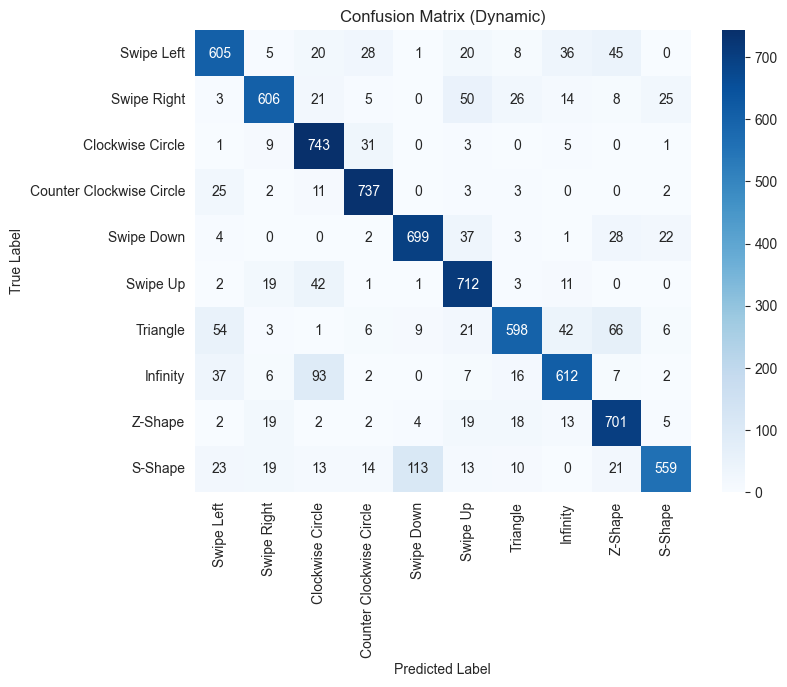

                          precision    recall  f1-score   support

              Swipe Left       0.80      0.79      0.79       768
             Swipe Right       0.88      0.80      0.84       758
        Clockwise Circle       0.79      0.94      0.85       793
Counter Clockwise Circle       0.89      0.94      0.91       783
              Swipe Down       0.85      0.88      0.86       796
                Swipe Up       0.80      0.90      0.85       791
                Triangle       0.87      0.74      0.80       806
                Infinity       0.83      0.78      0.81       782
                 Z-Shape       0.80      0.89      0.84       785
                 S-Shape       0.90      0.71      0.79       785

                accuracy                           0.84      7847
               macro avg       0.84      0.84      0.84      7847
            weighted avg       0.84      0.84      0.84      7847



In [6]:
if 'X_test' in locals():
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Dynamic)')
    plt.show()

    print(classification_report(y_test, y_pred, target_names=labels))


# 6. Trích xuất TFLite

In [7]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(tflite_save_path, 'wb') as f:
    f.write(tflite_model)
    
print(f"Done! Size = {os.path.getsize(tflite_save_path)} bytes")


INFO:tensorflow:Assets written to: C:\Users\TUFDAS~1\AppData\Local\Temp\tmp3up1get_\assets


INFO:tensorflow:Assets written to: C:\Users\TUFDAS~1\AppData\Local\Temp\tmp3up1get_\assets


Done! Size = 71004 bytes
